# Insurance Claims — Exploratory Data Analysis

Four tables: **Customers**, **Policies**, **Claims**, **External** (macro/weather).

Goals:
- Understand distributions and data quality
- Build an Analytical Base Table (ABT)
- Identify drivers of claim frequency and severity
- Construct model-ready target variables (frequency, severity, pure premium)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [7]:
path = r'C:\Users\DorothyCheruiyot\Desktop\Projects\insurance_claims\data\insurance_data_features.xlsx'

sheets = pd.read_excel(path, sheet_name=None, dtype=str)

customers, policies, claims, external = (
    sheets['Customers'],
    sheets['Policies'],
    sheets['Claims'],
    sheets['External']
)


In [8]:
customers.head()

,Customer Id,Age,Gender,Region,Income Band,Tenure Years,Credit Score,Payment Pattern,Late Payments 12M,Prior Claims Count,Occupation,Postcode District
0,CUST00001,58,M,North West,<20k,3,713,Direct Debit,0,2,Company secretary,L2 5
1,CUST00002,55,M,London,<20k,13,660,Credit Card,0,0,Early years teacher,G78
2,CUST00003,32,Other,South West,60-100k,0,532,Credit Card,1,0,Magazine journalist,TQ6V
3,CUST00004,46,M,North West,60-100k,8,602,Bank Transfer,2,1,Chartered public finance accountant,L8A
4,CUST00005,35,M,South East,60-100k,4,679,Direct Debit,0,0,Podiatrist,DL5Y


In [9]:
policies.head()

,Policy Id,Customer Id,Coverage Type,Start Date,End Date,Annual Premium,Excess Amount,Sum Insured,Policy Status,Renewal Count,Distribution Channel
0,POL000001,CUST00620,Life,2021-02-22 00:00:00,2021-08-21 00:00:00,384.22,500,33300,Active,4,Direct
1,POL000002,CUST07477,Travel,2021-08-04 00:00:00,2022-01-31 00:00:00,301.01,100,17400,Active,0,Bancassurance
2,POL000003,CUST06172,Travel,2021-11-30 00:00:00,2023-11-30 00:00:00,314.82,100,21800,Active,0,Broker
3,POL000004,CUST01111,Motor,2023-02-17 00:00:00,2024-02-17 00:00:00,455.55,200,39300,Active,2,Aggregator
4,POL000005,CUST04868,Life,2022-03-16 00:00:00,2023-03-16 00:00:00,1002.14,500,30400,Active,6,Bancassurance


In [10]:
claims.head()

,Claim Id,Policy Id,Customer Id,Claim Date,Claim Type,Claim Amount,Claim Status,Settlement Days,Settlement Date,Fraud Flag,Coverage Type
0,CLM0000001,POL001589,CUST04742,2021-02-28 00:00:00,Accident,3070.31,Settled,118,2021-06-26 00:00:00,0,Health
1,CLM0000002,POL010598,CUST09209,2024-07-18 00:00:00,Medical,2668.14,Settled,83,2024-10-09 00:00:00,0,Life
2,CLM0000003,POL002080,CUST01646,2022-11-16 00:00:00,Accident,19384.22,Settled,116,2023-03-12 00:00:00,0,Motor
3,CLM0000004,POL006528,CUST09866,2021-06-13 00:00:00,Theft,3965.53,Settled,13,2021-06-26 00:00:00,0,Motor
4,CLM0000005,POL006798,CUST07857,2024-10-27 00:00:00,Medical,2170.25,Pending,139,2025-03-15 00:00:00,0,Travel


In [11]:
external.head()

,Region,Year Month,Avg Rainfall Mm,Avg Wind Speed Kmh,Flood Risk Index,Gdp Growth Rate,Cpi Inflation,Unemployment Rate,Avg Property Price Gbp,Storm Event Flag
0,London,2010-01,15.8,15.8,1,0.0174,0.0286,0.0497,251500,0
1,London,2010-02,32.6,12,1.66,0.011,0.0463,0.0515,175000,0
2,London,2010-03,49.8,9.3,2.73,0.0272,0.0254,0.0597,192700,0
3,London,2010-04,52.2,13.9,3.01,0.0216,0.0184,0.0412,292100,0
4,London,2010-05,70.9,14.9,3.47,0.0221,0.0293,0.0332,264000,0


In [14]:
# numeric columns
# customers
for c in ['Age', 'Tenure Years', 'Credit Score', 'Late Payments 12M', 'Prior Claims Count']:
    customers[c] = pd.to_numeric(customers[c], errors='coerce')

# policies
for c in ['Annual Premium', 'Excess Amount', 'Sum Insured', 'Renewal Count']:
    policies[c] = pd.to_numeric(policies[c], errors='coerce')

policies['Start Date'] = pd.to_datetime(policies['Start Date'], errors='coerce')
policies['End Date'] = pd.to_datetime(policies['End Date'], errors='coerce')
policies['policy_duration_days'] = (policies['End Date'] - policies['Start Date']).dt.days

# claims
for c in ['Claim Amount', 'Settlement Days']:
    claims[c] = pd.to_numeric(claims[c], errors='coerce')

claims['Fraud Flag'] = pd.to_numeric(claims['Fraud Flag'], errors='coerce')
claims['Claim Date'] = pd.to_datetime(claims['Claim Date'], errors='coerce')
claims['Settlement Date'] = pd.to_datetime(claims['Settlement Date'], errors='coerce')
claims['year_month'] = claims['Claim Date'].dt.to_period('M')

# external
for c in ['Avg Rainfall Mm', 'Avg Wind Speed Kmh', 'Flood Risk Index',
          'Gdp Growth Rate', 'Cpi Inflation', 'Unemployment Rate',
          'Avg Property Price Gbp', 'Storm Event Flag']:
    external[c] = pd.to_numeric(external[c], errors='coerce')
external['year_month'] = pd.PeriodIndex(external['Year Month'], freq='M')



## 2. Data Quality

In [18]:
def quality_report(df):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(1)
    q = pd.DataFrame({'dtype': df.dtypes, 'nulls': miss, 'null_%': miss_pct, 'unique': df.nunique()})
    return q

quality_report(customers)
quality_report(policies)
quality_report(claims)
quality_report(external)

,dtype,nulls,null_%,unique
Region,str,0,0.0,10
Year Month,str,0,0.0,180
Avg Rainfall Mm,float64,0,0.0,717
Avg Wind Speed Kmh,float64,0,0.0,257
Flood Risk Index,float64,0,0.0,387
Gdp Growth Rate,float64,0,0.0,360
Cpi Inflation,float64,0,0.0,590
Unemployment Rate,float64,0,0.0,430
Avg Property Price Gbp,int64,0,0.0,1218
Storm Event Flag,int64,0,0.0,2


In [ ]:
# print(claims['Claim Status'].value_counts(normalize=True).mul(100).round(1))

# print(claims['Fraud Flag'].value_counts(normalize=True).mul(100).round(1))

# print(f"Policy duration (days) — min: {policies['policy_duration_days'].min():.0f}  "
#       f"max: {policies['policy_duration_days'].max():.0f}  "
#       f"median: {policies['policy_duration_days'].median():.0f}")

# orphan_claims = (~claims['Policy Id'].isin(policies['Policy Id'])).sum()
# print(f"\nOrphan claims: {orphan_claims}")

# merged_check = claims.merge(policies[['Policy Id', 'Customer Id']], on='Policy Id', suffixes=('_c', '_p'))
# custid_mismatch = (merged_check['Customer Id_c'] != merged_check['Customer Id_p']).sum()
# print(f"Customer Id mismatches (Claims vs Policies): {custid_mismatch}")
# print(f"External date range: {external['year_month'].min()} → {external['year_month'].max()}")
# print(f"Claims date range  : {claims['year_month'].min()} → {claims['year_month'].max()}")

## 3. Build Analytical Base Table (ABT)

In [20]:
abt = claims.merge(
    policies[['Policy Id', 'Customer Id', 'Coverage Type', 'Annual Premium',
              'Excess Amount', 'Sum Insured', 'Policy Status',
              'Renewal Count', 'Distribution Channel',
              'Start Date', 'End Date', 'policy_duration_days']],
    on='Policy Id', how='left', suffixes=('_claim', '_policy')
)
abt = abt.rename(columns={'Customer Id_claim': 'Customer Id'})
abt = abt.merge(
    customers[['Customer Id', 'Age', 'Gender', 'Region', 'Income Band',
               'Tenure Years', 'Credit Score', 'Payment Pattern',
               'Late Payments 12M', 'Prior Claims Count', 'Occupation']],
    on='Customer Id', how='left'
)
abt['year_month'] = abt['Claim Date'].dt.to_period('M')
abt = abt.merge(
    external.rename(columns={'Region': 'Region_ext'}),
    left_on=['Region', 'year_month'],
    right_on=['Region_ext', 'year_month'], how='left'
)

abt.head()


,Claim Id,Policy Id,Customer Id,Claim Date,Claim Type,Claim Amount,Claim Status,Settlement Days,Settlement Date,Fraud Flag,...,Region_ext,Year Month,Avg Rainfall Mm,Avg Wind Speed Kmh,Flood Risk Index,Gdp Growth Rate,Cpi Inflation,Unemployment Rate,Avg Property Price Gbp,Storm Event Flag
0,CLM0000001,POL001589,CUST04742,2021-02-28,Accident,3070.31,Settled,118,2021-06-26,0,...,East Anglia,2021-02,30.4,11.5,1.83,0.0115,0.0631,0.0539,328500,0
1,CLM0000002,POL010598,CUST09209,2024-07-18,Medical,2668.14,Settled,83,2024-10-09,0,...,Yorkshire,2024-07,78.5,20.5,3.55,0.0113,0.0406,0.0443,280400,0
2,CLM0000003,POL002080,CUST01646,2022-11-16,Accident,19384.22,Settled,116,2023-03-12,0,...,London,2022-11,17.4,13.0,1.00,0.0099,0.0385,0.0345,219700,1
3,CLM0000004,POL006528,CUST09866,2021-06-13,Theft,3965.53,Settled,13,2021-06-26,0,...,North West,2021-06,63.0,16.6,3.02,0.0195,0.0328,0.0374,357000,0
4,CLM0000005,POL006798,CUST07857,2024-10-27,Medical,2170.25,Pending,139,2025-03-15,0,...,East Anglia,2024-10,58.6,11.0,2.78,0.0076,0.0643,0.0355,252000,0


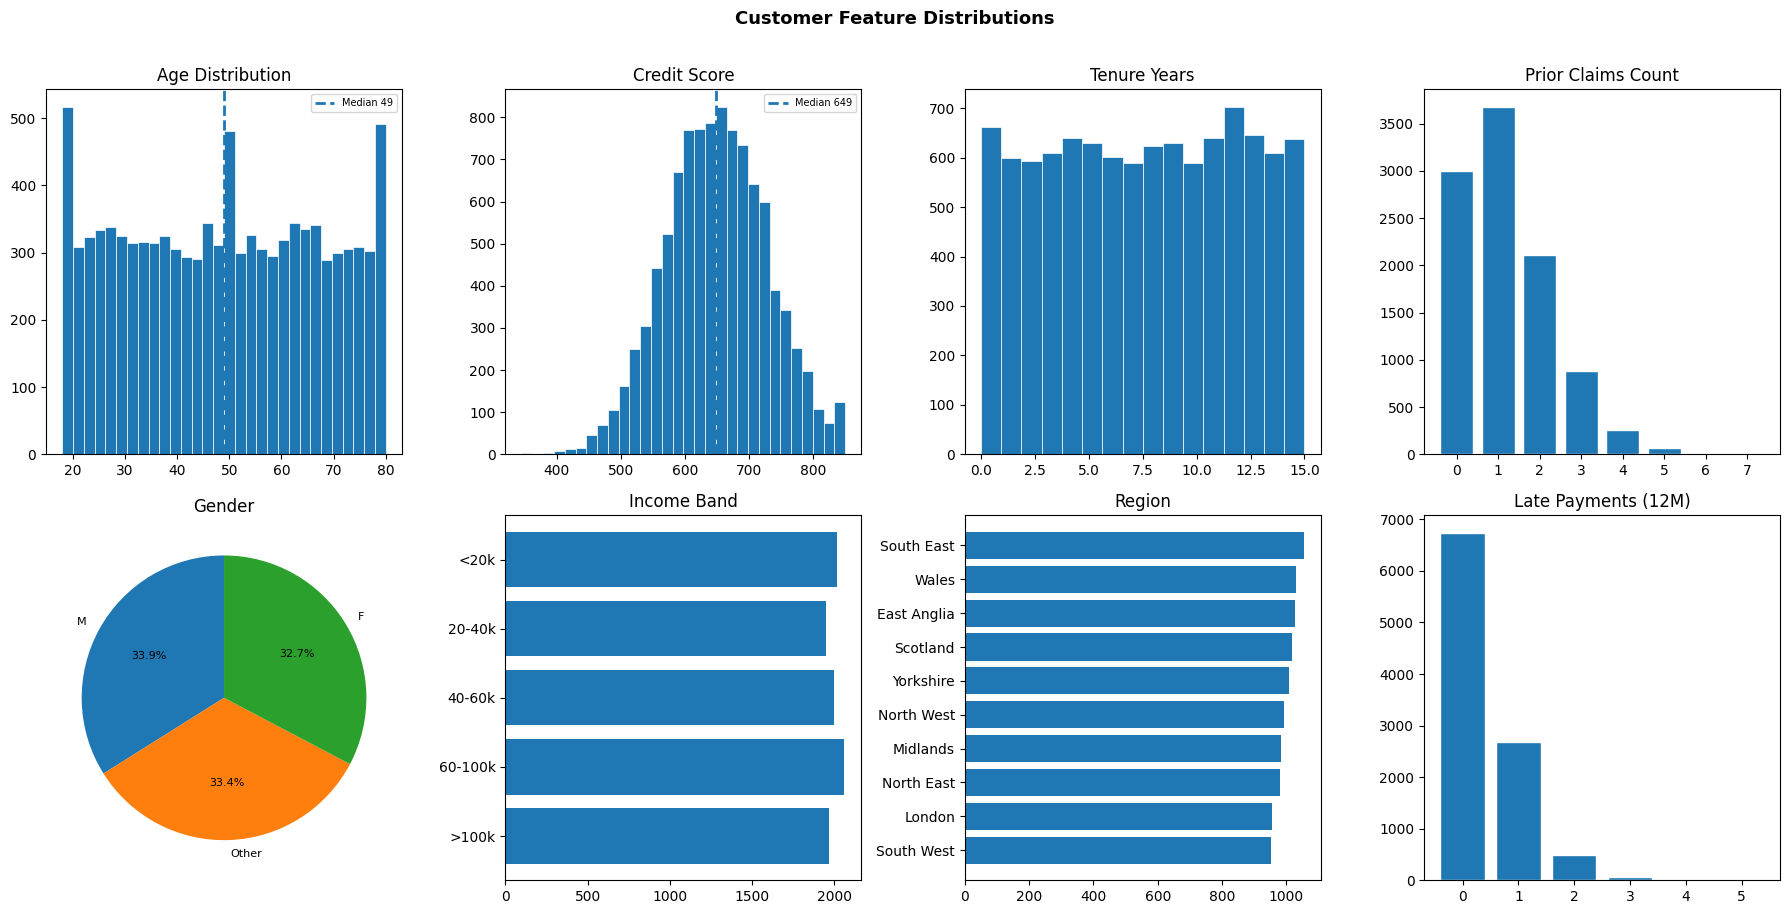

In [21]:
# customer features
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Customer Feature Distributions', fontsize=13, fontweight='bold', y=1.01)

ax = axes[0, 0]
ax.hist(customers['Age'].dropna(), bins=30, edgecolor='white', linewidth=0.5)
ax.axvline(customers['Age'].median(),  lw=2, ls='--', label=f"Median {customers['Age'].median():.0f}")
ax.set_title('Age Distribution'); ax.legend(fontsize=7)

ax = axes[0, 1]
ax.hist(customers['Credit Score'].dropna(), bins=30,  edgecolor='white', linewidth=0.5)
ax.axvline(customers['Credit Score'].median(),  lw=2, ls='--',
           label=f"Median {customers['Credit Score'].median():.0f}")
ax.set_title('Credit Score'); ax.legend(fontsize=7)

ax = axes[0, 2]
ax.hist(customers['Tenure Years'].dropna(), bins=16,  edgecolor='white', linewidth=0.5)
ax.set_title('Tenure Years')

ax = axes[0, 3]
vc = customers['Prior Claims Count'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values,  edgecolor='white')
ax.set_title('Prior Claims Count')

ax = axes[1, 0]
vc = customers['Gender'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 8})
ax.set_title('Gender')

ax = axes[1, 1]
order = ['<20k', '20-40k', '40-60k', '60-100k', '>100k']
vc = customers['Income Band'].value_counts().reindex(order).fillna(0)
ax.barh(vc.index, vc.values)
ax.set_title('Income Band'); ax.invert_yaxis()

ax = axes[1, 2]
vc = customers['Region'].value_counts()
ax.barh(vc.index, vc.values)
ax.set_title('Region'); ax.invert_yaxis()

ax = axes[1, 3]
vc = customers['Late Payments 12M'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, edgecolor='white')
ax.set_title('Late Payments (12M)')

plt.tight_layout()
plt.show()

In [8]:
customers.groupby('Prior Claims Count')['Credit Score'].agg(['mean', 'median', 'count']).round(1)

,mean,median,count
Prior Claims Count,,,
0,649.0,647.0,3002
1,648.2,648.0,3679
2,652.3,651.0,2108
3,652.6,652.0,877
4,642.5,643.5,260
5,652.6,660.0,63
6,622.8,606.5,8
7,647.0,689.0,3


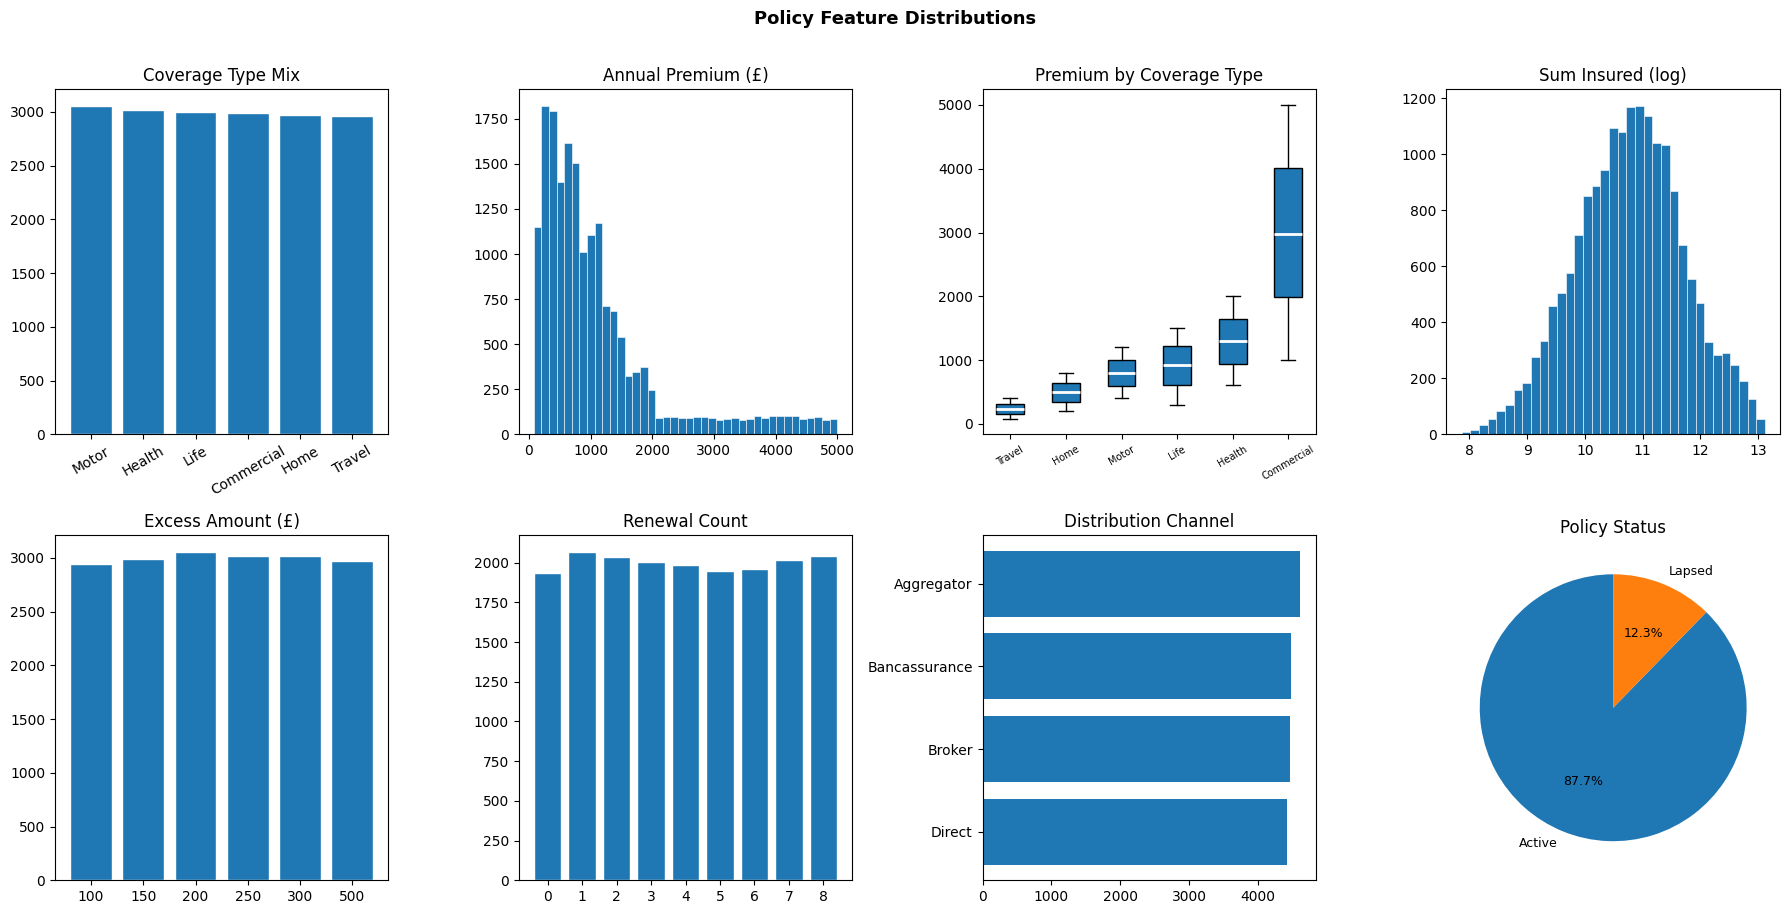

In [24]:
# Policy features
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Policy Feature Distributions', fontsize=13, fontweight='bold', y=1.01)

ax = axes[0, 0]
vc = policies['Coverage Type'].value_counts()
ax.bar(vc.index, vc.values, edgecolor='white')
ax.set_title('Coverage Type Mix'); ax.tick_params(axis='x', rotation=30)

ax = axes[0, 1]
ax.hist(policies['Annual Premium'].dropna(), bins=40, edgecolor='white', linewidth=0.4)
ax.set_title('Annual Premium (£)')

ax = axes[0, 2]
cov_order = policies.groupby('Coverage Type')['Annual Premium'].median().sort_values().index
bp_data = [policies[policies['Coverage Type'] == c]['Annual Premium'].dropna().values for c in cov_order]
bp = ax.boxplot(bp_data, patch_artist=True, medianprops={'color': 'white', 'linewidth': 2})

ax.set_xticklabels(cov_order, rotation=30, fontsize=7)
ax.set_title('Premium by Coverage Type')

ax = axes[0, 3]
ax.hist(np.log1p(policies['Sum Insured'].dropna()), bins=35, edgecolor='white', linewidth=0.4)
ax.set_title('Sum Insured (log)')

ax = axes[1, 0]
vc = policies['Excess Amount'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, edgecolor='white')
ax.set_title('Excess Amount (£)')

ax = axes[1, 1]
vc = policies['Renewal Count'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, edgecolor='white')
ax.set_title('Renewal Count')

ax = axes[1, 2]
vc = policies['Distribution Channel'].value_counts()
ax.barh(vc.index, vc.values)
ax.set_title('Distribution Channel'); ax.invert_yaxis()

ax = axes[1, 3]
vc = policies['Policy Status'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 9})
ax.set_title('Policy Status')

plt.tight_layout()
plt.show()

In [10]:
policies.groupby('Coverage Type')[['Annual Premium', 'Sum Insured']].agg(['min', 'median', 'mean', 'max']).round(0)

Annual Premium                         Sum Insured            \
                         min  median    mean     max         min    median   
Coverage Type                                                                
Commercial            1000.0  2977.0  2990.0  5000.0       30900  171200.0   
Health                 601.0  1291.0  1296.0  2000.0       18900   77600.0   
Home                   200.0   495.0   496.0   800.0        6400   29400.0   
Life                   301.0   924.0   910.0  1500.0        9300   52900.0   
Motor                  400.0   793.0   800.0  1199.0       13000   48100.0   
Travel                  80.0   240.0   240.0   400.0        2600   14100.0   

                                 
                   mean     max  
Coverage Type                    
Commercial     192099.0  497400  
Health          84122.0  198200  
Home            32321.0   79700  
Life            58757.0  145300  
Motor           51879.0  118000  
Travel          15692.0   39300

## 6. Claims Distributions

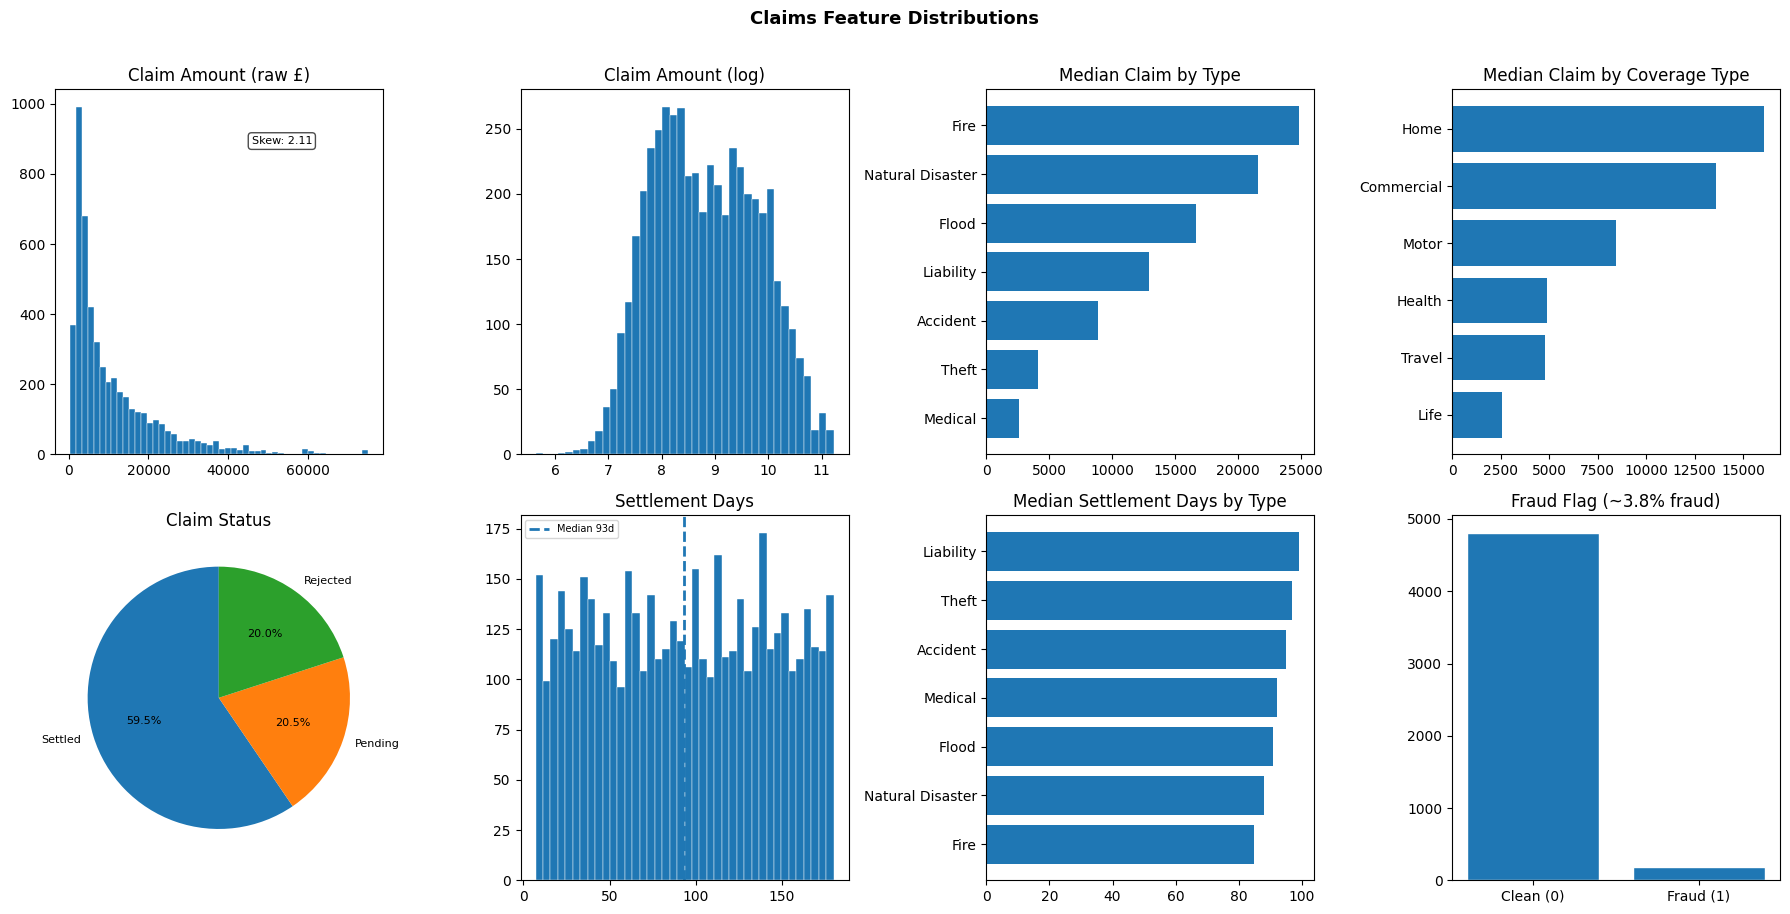

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Claims Feature Distributions', fontsize=13, fontweight='bold', y=1.01)

ax = axes[0, 0]
ax.hist(claims['Claim Amount'].dropna(), bins=50, edgecolor='white', linewidth=0.3)
ax.set_title('Claim Amount (raw £)')
ax.text(0.6, 0.85, f'Skew: {claims["Claim Amount"].skew():.2f}', transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax = axes[0, 1]
ax.hist(np.log1p(claims['Claim Amount'].dropna()), bins=40, edgecolor='white', linewidth=0.3)
ax.set_title('Claim Amount (log)')

ax = axes[0, 2]
ct_med = claims.groupby('Claim Type')['Claim Amount'].median().sort_values()
ax.barh(ct_med.index, ct_med.values)
ax.set_title('Median Claim by Type')

ax = axes[0, 3]
cov_med = claims.groupby('Coverage Type')['Claim Amount'].median().sort_values()
ax.barh(cov_med.index, cov_med.values)
ax.set_title('Median Claim by Coverage Type')

ax = axes[1, 0]
vc = claims['Claim Status'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax.set_title('Claim Status')

ax = axes[1, 1]
sd = claims['Settlement Days'].dropna()
ax.hist(sd, bins=40, edgecolor='white', linewidth=0.3)
ax.axvline(sd.median(), lw=2, ls='--', label=f'Median {sd.median():.0f}d')
ax.set_title('Settlement Days'); ax.legend(fontsize=7)

ax = axes[1, 2]
ct_sd = claims.groupby('Claim Type')['Settlement Days'].median().sort_values()
ax.barh(ct_sd.index, ct_sd.values)
ax.set_title('Median Settlement Days by Type')

ax = axes[1, 3]
vc = claims['Fraud Flag'].value_counts()
ax.bar(['Clean (0)', 'Fraud (1)'],
       [vc.get(0.0, vc.get(0, 0)), vc.get(1.0, vc.get(1, 0))],edgecolor='white')
ax.set_title(f'Fraud Flag (~{claims["Fraud Flag"].mean()*100:.1f}% fraud)')

plt.tight_layout()
plt.show()

In [12]:
claims.groupby('Claim Type')['Claim Amount'].agg(['count', 'min', 'median', 'mean', 'max']).round(0)

,count,min,median,mean,max
Claim Type,,,,,
Accident,711,2000.0,8897.0,9880.0,22500.0
Fire,439,5885.0,24828.0,29367.0,75000.0
Flood,411,3687.0,16668.0,18881.0,45000.0
Liability,493,3352.0,12928.0,14613.0,37500.0
Medical,1522,279.0,2627.0,2943.0,7500.0
Natural Disaster,457,4000.0,21609.0,23875.0,60000.0
Theft,967,800.0,4119.0,4619.0,12000.0


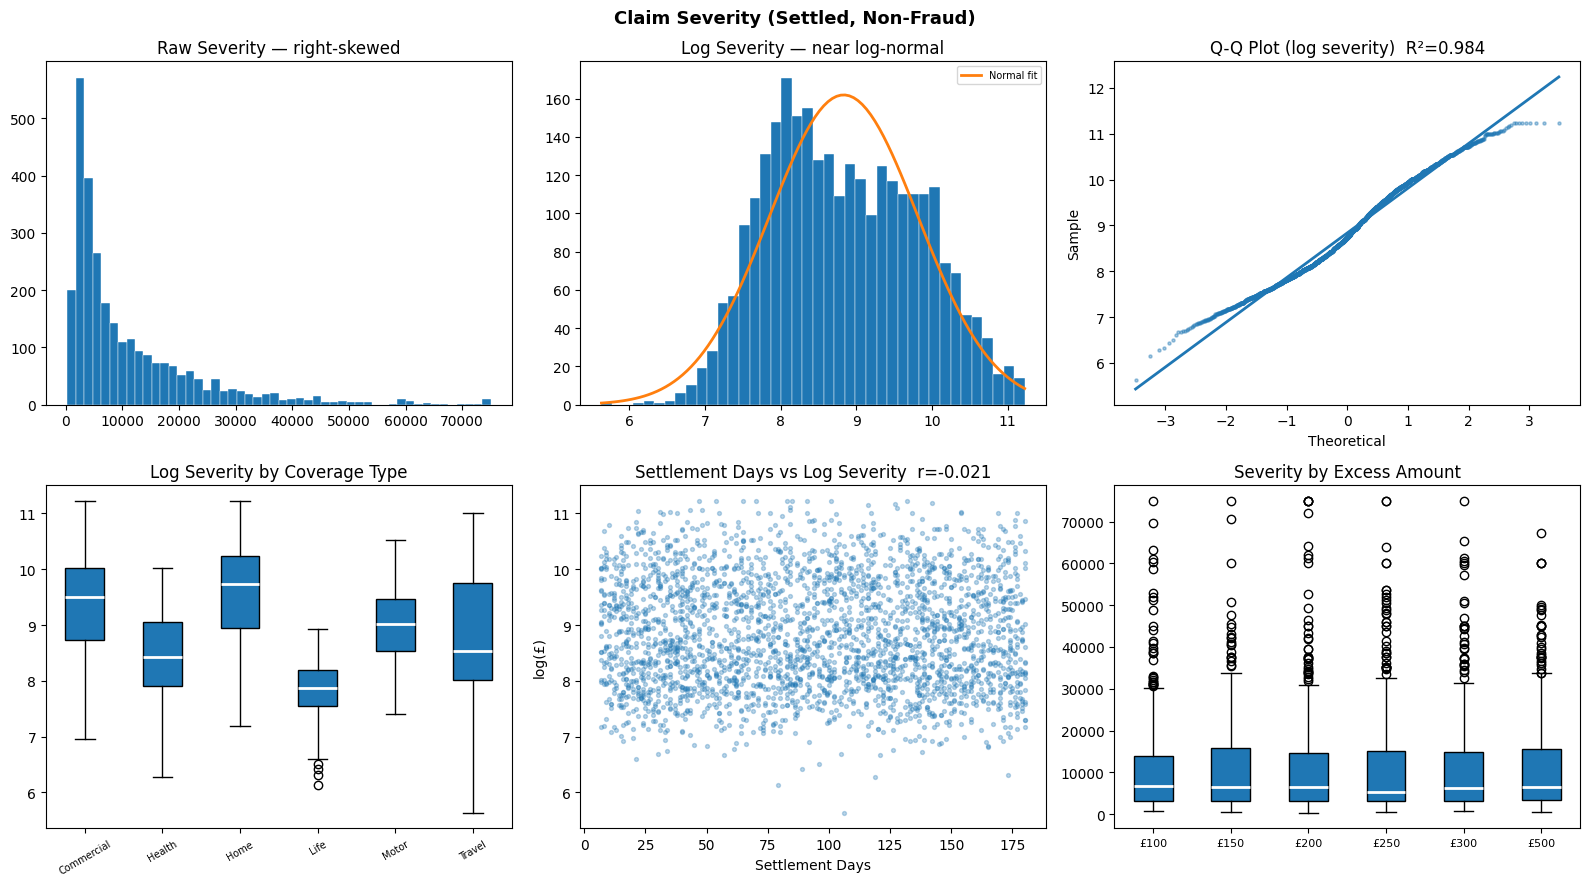

In [31]:
# claim severity analysis
abt_settled = abt[(abt['Claim Status'] == 'Settled') & (abt['Fraud Flag'] == 0)].copy()
abt_settled['log_claim_amount'] = np.log1p(abt_settled['Claim Amount'])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Claim Severity (Settled, Non-Fraud)', fontsize=13, fontweight='bold')

ax = axes[0, 0]
ax.hist(abt_settled['Claim Amount'], bins=50, edgecolor='white', linewidth=0.3)
ax.set_title('Raw Severity — right-skewed')

ax = axes[0, 1]
vals = abt_settled['log_claim_amount'].dropna()
ax.hist(vals, bins=40, edgecolor='white', linewidth=0.3)
mu, sigma = vals.mean(), vals.std()
x = np.linspace(vals.min(), vals.max(), 100)
ax.plot(x, stats.norm.pdf(x, mu, sigma) * len(vals) * (vals.max() - vals.min()) / 40, lw=2, label='Normal fit')
ax.set_title('Log Severity — near log-normal'); ax.legend(fontsize=7)

ax = axes[0, 2]
(osm, osr), (slope, intercept, r) = stats.probplot(vals, dist='norm')
ax.scatter(osm, osr, s=5, alpha=0.4)
ax.plot(osm, slope * np.array(osm) + intercept, lw=2)
ax.set_title(f'Q-Q Plot (log severity)  R²={r**2:.3f}')
ax.set_xlabel('Theoretical'); ax.set_ylabel('Sample')

ax = axes[1, 0]
cov_types = sorted(abt_settled['Coverage Type_policy'].dropna().unique())
bp_data = [abt_settled[abt_settled['Coverage Type_policy'] == c]['log_claim_amount'].dropna().values for c in cov_types]
bp = ax.boxplot(bp_data, patch_artist=True, medianprops={'color': 'white', 'linewidth': 2})

ax.set_xticklabels(cov_types, rotation=30, fontsize=7)
ax.set_title('Log Severity by Coverage Type')

ax = axes[1, 1]
sd_valid = abt_settled.dropna(subset=['Settlement Days', 'log_claim_amount'])
ax.scatter(sd_valid['Settlement Days'], sd_valid['log_claim_amount'], s=8, alpha=0.3)
corr_sd = sd_valid['Settlement Days'].corr(sd_valid['log_claim_amount'])
ax.set_title(f'Settlement Days vs Log Severity  r={corr_sd:.3f}')
ax.set_xlabel('Settlement Days'); ax.set_ylabel('log(£)')

ax = axes[1, 2]
exc_order = sorted(abt_settled['Excess Amount'].dropna().unique())
bp_data = [abt_settled[abt_settled['Excess Amount'] == e]['Claim Amount'].dropna().values for e in exc_order]
bp = ax.boxplot(bp_data, patch_artist=True, medianprops={'color': 'white', 'linewidth': 2})

ax.set_xticklabels([f'£{int(e)}' for e in exc_order], fontsize=8)
ax.set_title('Severity by Excess Amount')

plt.tight_layout()
plt.show()

In [ ]:
# print(abt_settled['Claim Amount'].describe().round(0))

# samp = vals.sample(min(500, len(vals)), random_state=42)
# stat, p = stats.shapiro(samp)
# verdict = '→ log-normal holds' if p > 0.05 else '→ some deviation (heavy tail)'
# print(f"\nShapiro-Wilk on log severity (n=500): stat={stat:.4f}, p={p:.4f}  {verdict}")

## 8. External Features

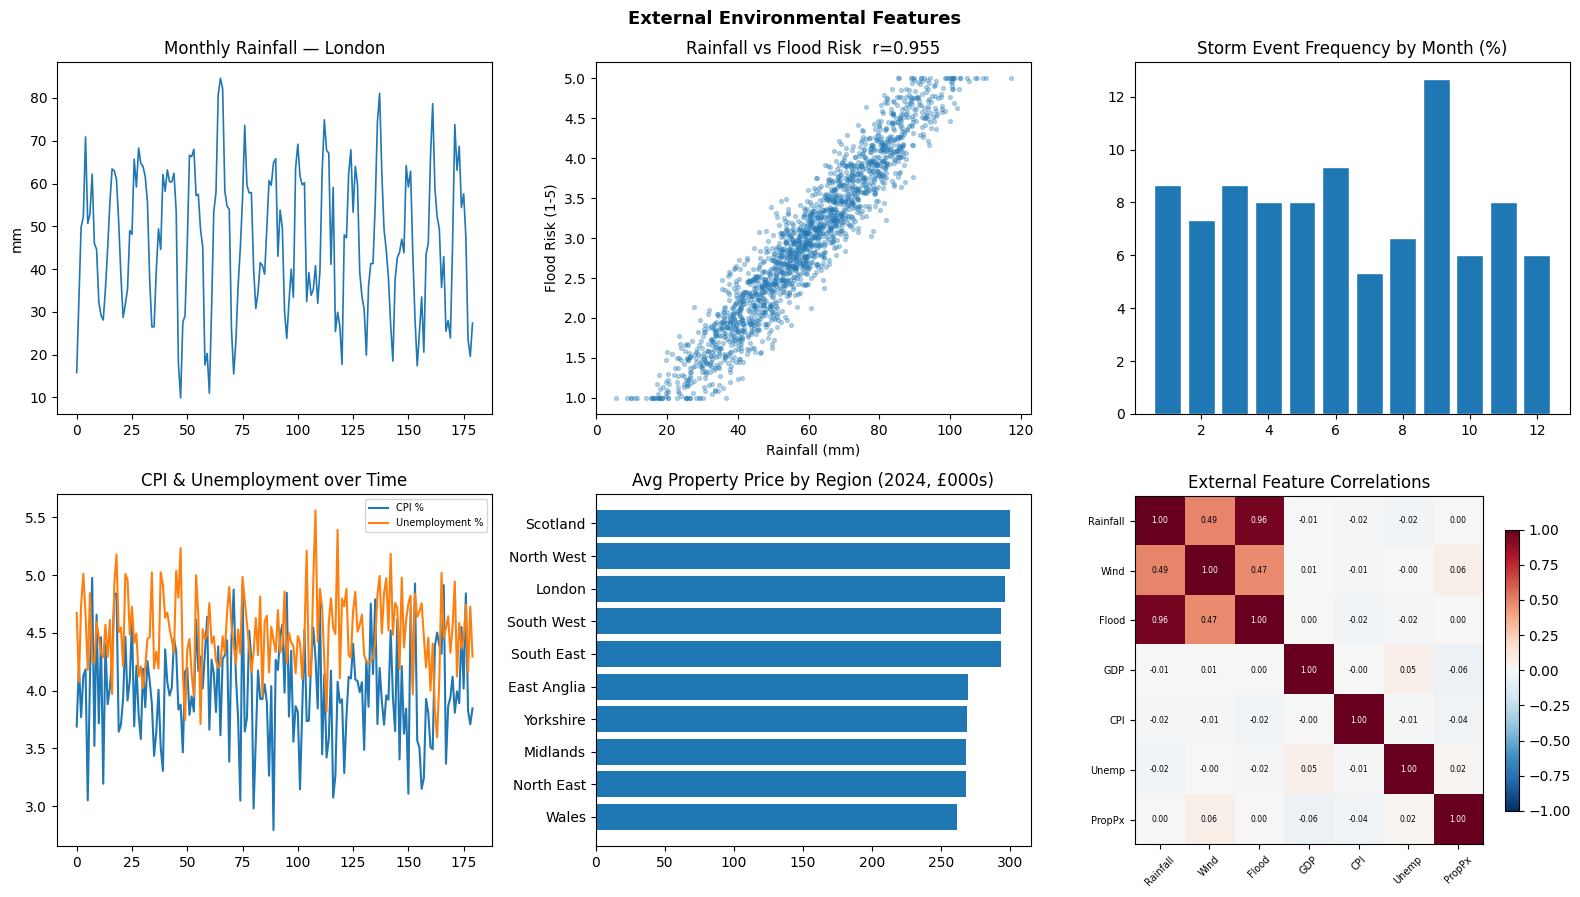

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('External Environmental Features', fontsize=13, fontweight='bold')

ax = axes[0, 0]
lon = external[external['Region'] == 'London'].sort_values('year_month')
ax.plot(range(len(lon)), lon['Avg Rainfall Mm'].values, lw=1.2)
ax.set_title('Monthly Rainfall — London'); ax.set_ylabel('mm')

ax = axes[0, 1]
ax.scatter(external['Avg Rainfall Mm'], external['Flood Risk Index'], s=8, alpha=0.3, )
corr_rf = external['Avg Rainfall Mm'].corr(external['Flood Risk Index'])
ax.set_title(f'Rainfall vs Flood Risk  r={corr_rf:.3f}')
ax.set_xlabel('Rainfall (mm)'); ax.set_ylabel('Flood Risk (1-5)')

ax = axes[0, 2]
ext_cp = external.copy()
ext_cp['month'] = ext_cp['year_month'].apply(lambda x: x.month)
storm_by_month = ext_cp.groupby('month')['Storm Event Flag'].mean() * 100
ax.bar(storm_by_month.index, storm_by_month.values, edgecolor='white')
ax.set_title('Storm Event Frequency by Month (%)')

ax = axes[1, 0]
ext_ts = external.groupby('year_month')[['Cpi Inflation', 'Unemployment Rate']].mean()
ax.plot(range(len(ext_ts)), ext_ts['Cpi Inflation'].values * 100, lw=1.5, label='CPI %')
ax.plot(range(len(ext_ts)), ext_ts['Unemployment Rate'].values * 100, lw=1.5, label='Unemployment %')
ax.set_title('CPI & Unemployment over Time'); ax.legend(fontsize=7)

ax = axes[1, 1]
latest_yr = external['year_month'].max().year
ext_latest = external[external['year_month'].apply(lambda x: x.year) == latest_yr]
pp = ext_latest.groupby('Region')['Avg Property Price Gbp'].mean().sort_values()
ax.barh(pp.index, pp.values / 1000)
ax.set_title(f'Avg Property Price by Region ({latest_yr}, £000s)')

ax = axes[1, 2]
ext_num = external[['Avg Rainfall Mm', 'Avg Wind Speed Kmh', 'Flood Risk Index',
                     'Gdp Growth Rate', 'Cpi Inflation', 'Unemployment Rate', 'Avg Property Price Gbp']].corr()
labels = ['Rainfall', 'Wind', 'Flood', 'GDP', 'CPI', 'Unemp', 'PropPx']
im = ax.imshow(ext_num.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, fontsize=7); ax.set_yticklabels(labels, fontsize=7)
for i in range(len(ext_num)):
    for j in range(len(ext_num)):
        v = ext_num.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5.5,
                color='white' if abs(v) > 0.5 else 'black')
ax.set_title('External Feature Correlations')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

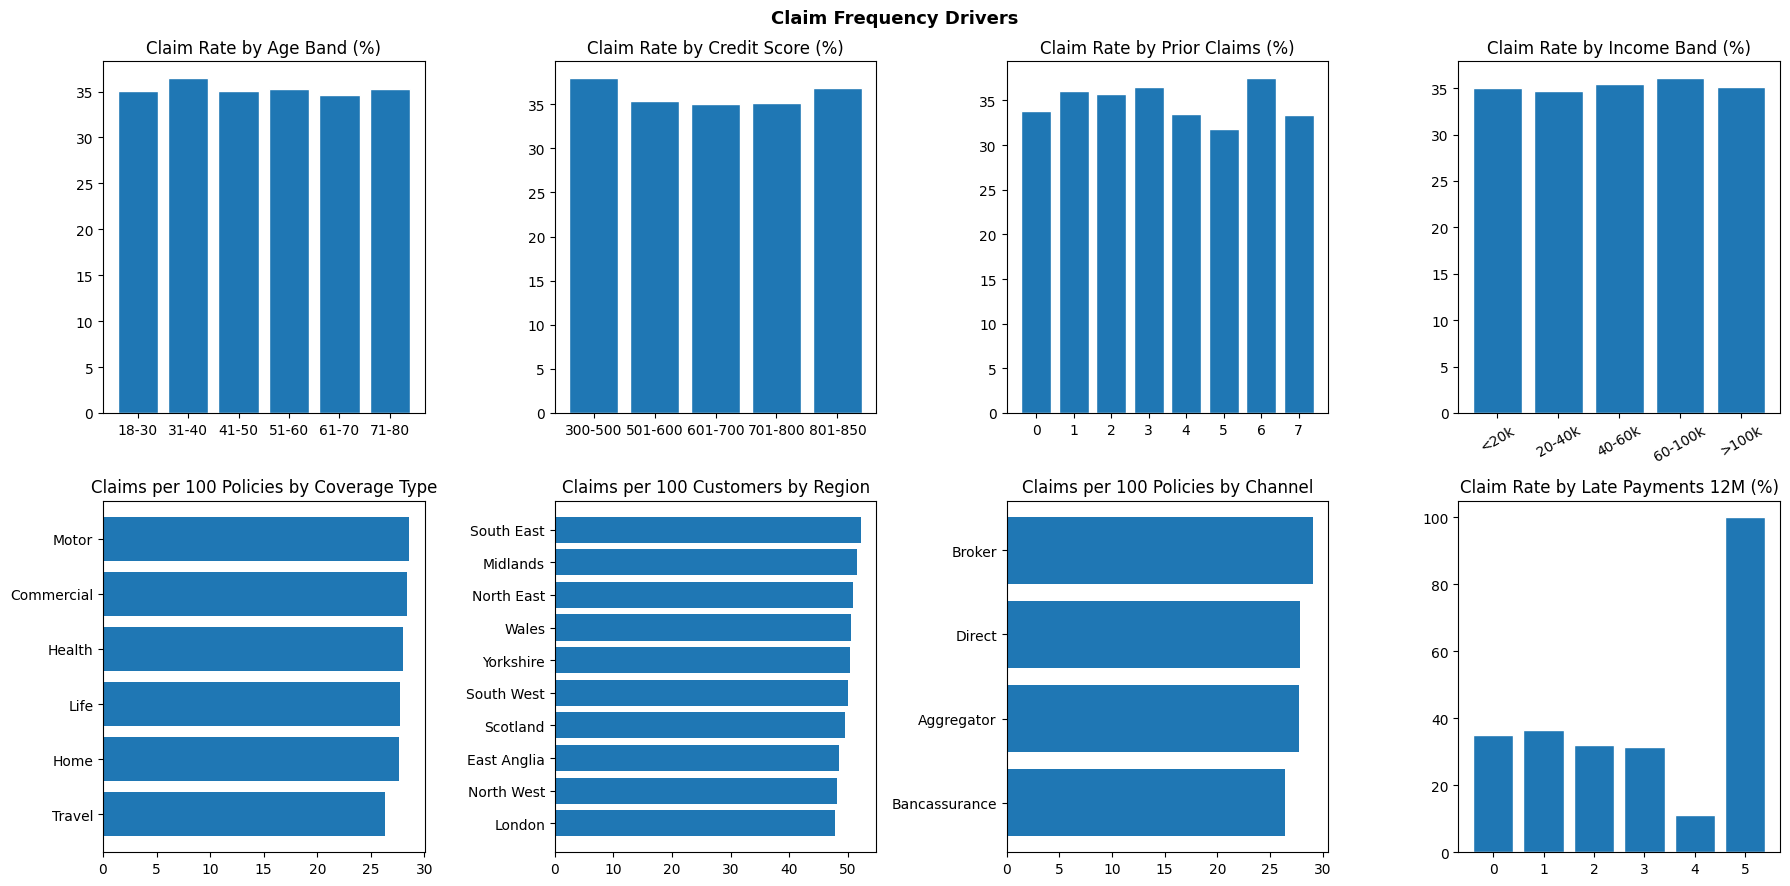

In [33]:
# claim frequency analysis
claims_per_cust = abt.groupby('Customer Id').size().reset_index(name='claim_n')
cust_enriched = customers.merge(claims_per_cust, on='Customer Id', how='left')
cust_enriched['claim_n']   = cust_enriched['claim_n'].fillna(0)
cust_enriched['has_claim'] = (cust_enriched['claim_n'] > 0).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Claim Frequency Drivers', fontsize=13, fontweight='bold')

ax = axes[0, 0]
cust_enriched['age_band'] = pd.cut(cust_enriched['Age'],
    bins=[17, 30, 40, 50, 60, 70, 80], labels=['18-30', '31-40', '41-50', '51-60', '61-70', '71-80'])
rate = cust_enriched.groupby('age_band', observed=True)['has_claim'].mean() * 100
ax.bar(rate.index.astype(str), rate.values, edgecolor='white')
ax.set_title('Claim Rate by Age Band (%)')

ax = axes[0, 1]
cust_enriched['cs_band'] = pd.cut(cust_enriched['Credit Score'],
    bins=[299, 500, 600, 700, 800, 850], labels=['300-500', '501-600', '601-700', '701-800', '801-850'])
rate = cust_enriched.groupby('cs_band', observed=True)['has_claim'].mean() * 100
ax.bar(rate.index.astype(str), rate.values, edgecolor='white')
ax.set_title('Claim Rate by Credit Score (%)')

ax = axes[0, 2]
rate = cust_enriched.groupby('Prior Claims Count')['has_claim'].mean() * 100
ax.bar(rate.index.astype(str), rate.values, edgecolor='white')
ax.set_title('Claim Rate by Prior Claims (%)')

ax = axes[0, 3]
order = ['<20k', '20-40k', '40-60k', '60-100k', '>100k']
rate = cust_enriched.groupby('Income Band')['has_claim'].mean().reindex(order) * 100
ax.bar(rate.index, rate.values, edgecolor='white')
ax.set_title('Claim Rate by Income Band (%)'); ax.tick_params(axis='x', rotation=30)

ax = axes[1, 0]
cov_col = 'Coverage Type' if 'Coverage Type' in abt.columns else 'Coverage Type_claim'
freq_cov = abt.groupby(cov_col).size()
pols_cov  = policies['Coverage Type'].value_counts()
rate_cov  = (freq_cov / pols_cov * 100).sort_values().dropna()
ax.barh(rate_cov.index, rate_cov.values)
ax.set_title('Claims per 100 Policies by Coverage Type')

ax = axes[1, 1]
region_claims = abt.groupby('Region').size()
region_custs  = customers['Region'].value_counts()
rate_r = (region_claims / region_custs * 100).sort_values().dropna()
ax.barh(rate_r.index, rate_r.values)
ax.set_title('Claims per 100 Customers by Region')

ax = axes[1, 2]
chan_col = 'Distribution Channel'
abt_chan = abt.merge(policies[['Policy Id', chan_col]], on='Policy Id', how='left', suffixes=('', '_p'))
use_col  = chan_col + '_p' if chan_col + '_p' in abt_chan.columns else chan_col
chan_claims = abt_chan.groupby(use_col).size()
chan_pols   = policies[chan_col].value_counts()
rate_c = (chan_claims / chan_pols * 100).sort_values().dropna()
ax.barh(rate_c.index, rate_c.values)
ax.set_title('Claims per 100 Policies by Channel')

ax = axes[1, 3]
rate_lp = cust_enriched.groupby('Late Payments 12M')['has_claim'].mean() * 100
ax.bar(rate_lp.index.astype(str), rate_lp.values, edgecolor='white')
ax.set_title('Claim Rate by Late Payments 12M (%)')

plt.tight_layout()
plt.show()

## 10. Severity Drivers

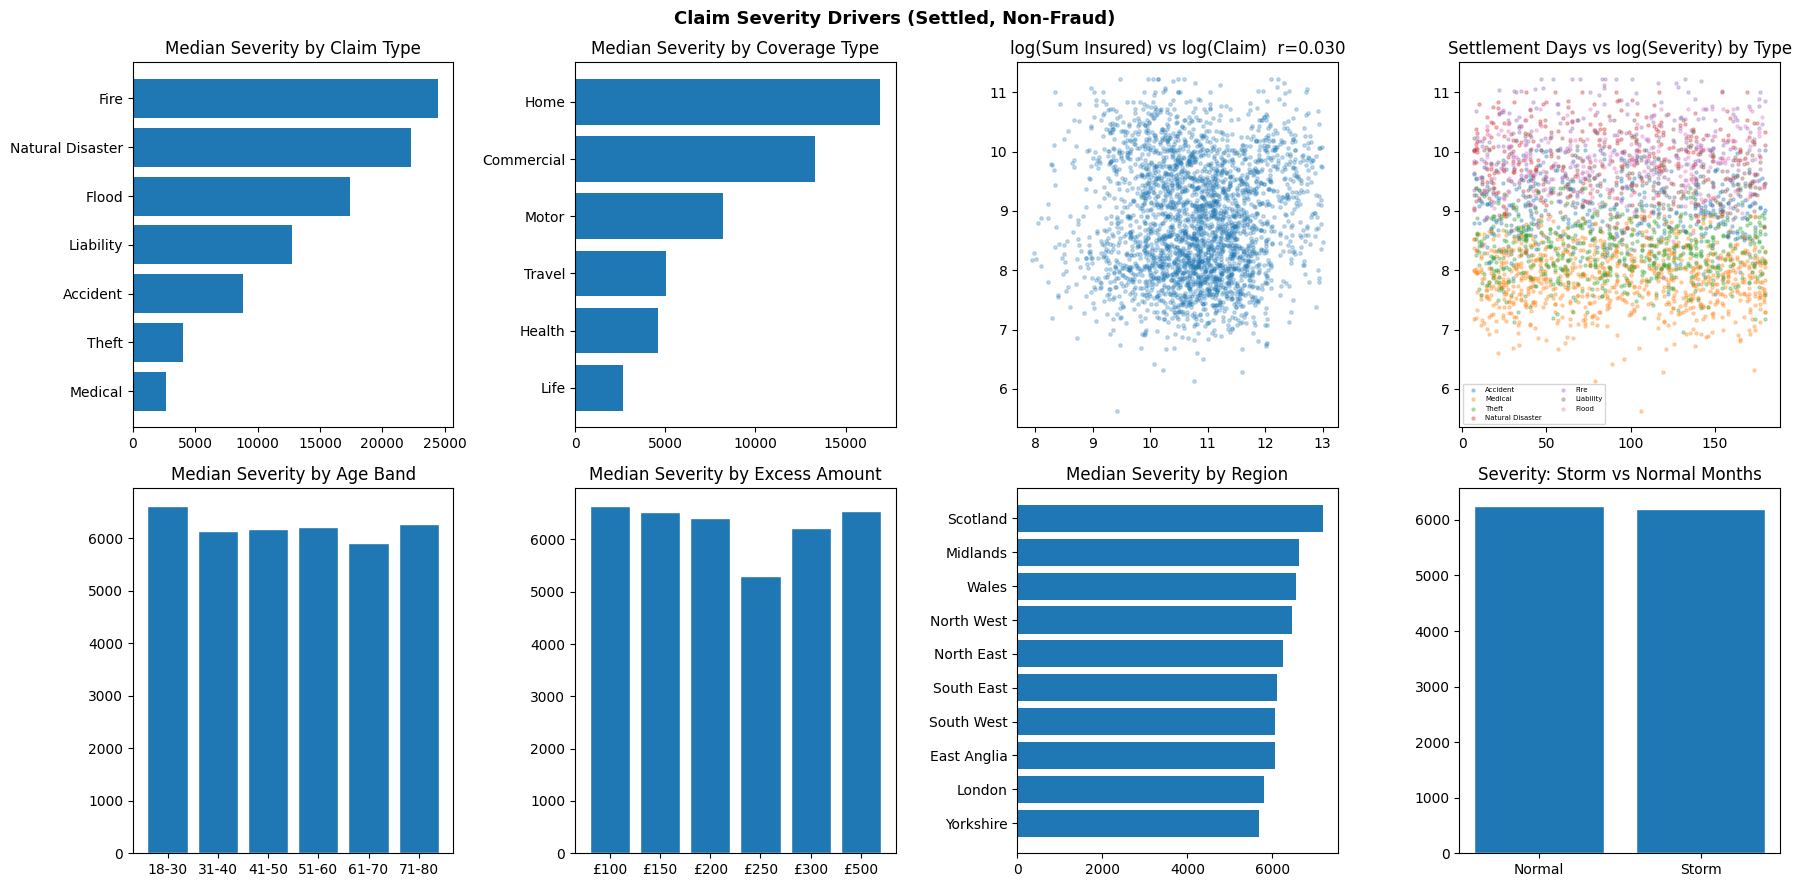

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Claim Severity Drivers (Settled, Non-Fraud)', fontsize=13, fontweight='bold')

ax = axes[0, 0]
ct = abt_settled.groupby('Claim Type')['Claim Amount'].median().sort_values()
ax.barh(ct.index, ct.values)
ax.set_title('Median Severity by Claim Type')

ax = axes[0, 1]
cov = abt_settled.groupby('Coverage Type_policy')['Claim Amount'].median().sort_values()
ax.barh(cov.index, cov.values)
ax.set_title('Median Severity by Coverage Type')

ax = axes[0, 2]
valid = abt_settled.dropna(subset=['Sum Insured', 'log_claim_amount'])
ax.scatter(np.log1p(valid['Sum Insured']), valid['log_claim_amount'], s=6, alpha=0.25)
corr_si = np.log1p(valid['Sum Insured']).corr(valid['log_claim_amount'])
ax.set_title(f'log(Sum Insured) vs log(Claim)  r={corr_si:.3f}')

ax = axes[0, 3]
for i, ct_name in enumerate(abt_settled['Claim Type'].dropna().unique()):
    sub = abt_settled[abt_settled['Claim Type'] == ct_name].dropna(subset=['Settlement Days', 'log_claim_amount'])
    ax.scatter(sub['Settlement Days'], sub['log_claim_amount'],
               s=5, alpha=0.3, label=ct_name)
ax.set_title('Settlement Days vs log(Severity) by Type')
ax.legend(fontsize=5, ncol=2)

ax = axes[1, 0]
abt_settled['age_band2'] = pd.cut(abt_settled['Age'],
    bins=[17, 30, 40, 50, 60, 70, 80], labels=['18-30', '31-40', '41-50', '51-60', '61-70', '71-80'])
sev_age = abt_settled.groupby('age_band2', observed=True)['Claim Amount'].median()
ax.bar(sev_age.index.astype(str), sev_age.values, edgecolor='white')
ax.set_title('Median Severity by Age Band')

ax = axes[1, 1]
sev_exc = abt_settled.groupby('Excess Amount')['Claim Amount'].median().sort_index()
ax.bar([f'£{int(e)}' for e in sev_exc.index], sev_exc.values, edgecolor='white')
ax.set_title('Median Severity by Excess Amount')

ax = axes[1, 2]
sev_reg = abt_settled.groupby('Region')['Claim Amount'].median().sort_values()
ax.barh(sev_reg.index, sev_reg.values)
ax.set_title('Median Severity by Region')

ax = axes[1, 3]
storm_sev  = abt_settled[abt_settled['Storm Event Flag'] == 1]['Claim Amount'].median()
normal_sev = abt_settled[abt_settled['Storm Event Flag'] == 0]['Claim Amount'].median()
ax.bar(['Normal', 'Storm'], [normal_sev, storm_sev], edgecolor='white')
ax.set_title('Severity: Storm vs Normal Months')

plt.tight_layout()
plt.show()

## 11. Temporal Analysis

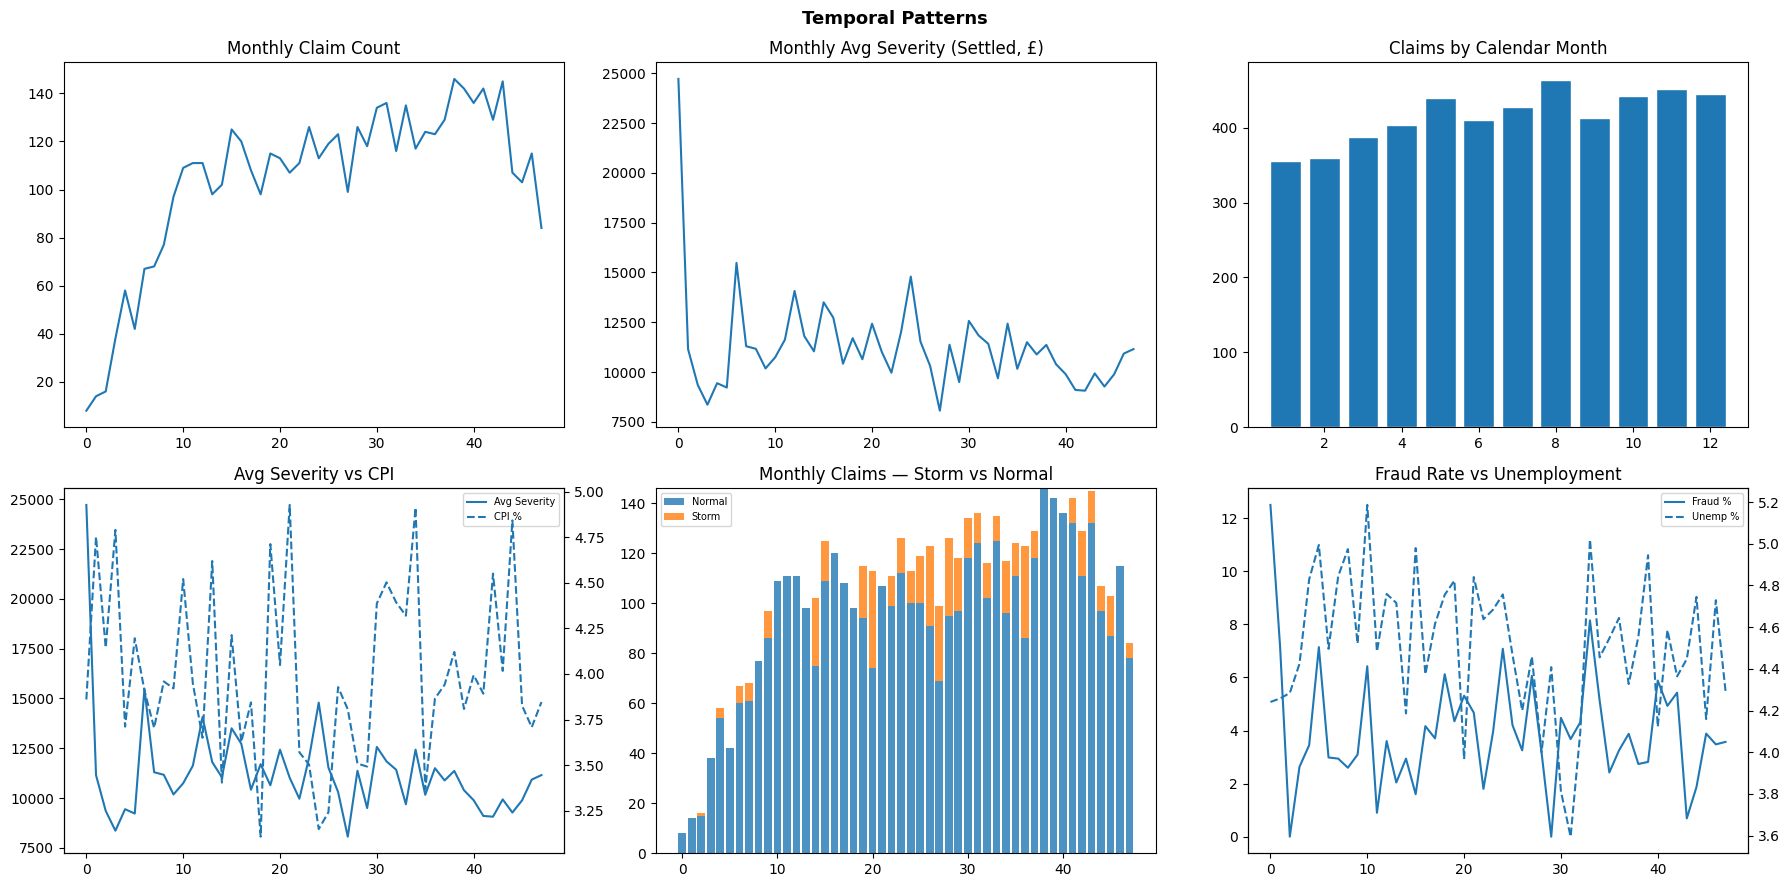

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Temporal Patterns', fontsize=13, fontweight='bold')

ax = axes[0, 0]
monthly = abt.groupby('year_month').size()
ax.plot(range(len(monthly)), monthly.values, lw=1.5)
ax.set_title('Monthly Claim Count')

ax = axes[0, 1]
monthly_sev = abt_settled.groupby('year_month')['Claim Amount'].mean()
ax.plot(range(len(monthly_sev)), monthly_sev.values, lw=1.5)
ax.set_title('Monthly Avg Severity (Settled, £)')

ax = axes[0, 2]
abt['cal_month'] = abt['Claim Date'].dt.month
seasonal = abt.groupby('cal_month').size()
ax.bar(seasonal.index, seasonal.values, edgecolor='white')
ax.set_title('Claims by Calendar Month')

ax = axes[1, 0]
sev_ts = abt_settled.groupby('year_month')['Claim Amount'].mean().reset_index()
sev_ts.columns = ['year_month', 'avg_severity']
ext_cpi = external.groupby('year_month')['Cpi Inflation'].mean().reset_index()
merged_ts = sev_ts.merge(ext_cpi, on='year_month').sort_values('year_month')
ax2 = ax.twinx()
ax.plot(range(len(merged_ts)), merged_ts['avg_severity'].values, lw=1.5, label='Avg Severity')
ax2.plot(range(len(merged_ts)), merged_ts['Cpi Inflation'].values * 100, lw=1.5, ls='--', label='CPI %')
ax.set_title('Avg Severity vs CPI')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, fontsize=7)

ax = axes[1, 1]
abt_storm = abt.merge(external[['Region', 'year_month', 'Storm Event Flag']],
                       on=['Region', 'year_month'], how='left', suffixes=('', '_ext'))
storm_col = 'Storm Event Flag_ext' if 'Storm Event Flag_ext' in abt_storm.columns else 'Storm Event Flag'
grp = abt_storm.groupby(['year_month', storm_col]).size().unstack(fill_value=0)
if 0.0 in grp.columns and 1.0 in grp.columns:
    ax.bar(range(len(grp)), grp[0.0].values, label='Normal', alpha=0.8)
    ax.bar(range(len(grp)), grp[1.0].values,label='Storm', alpha=0.8, bottom=grp[0.0].values)
    ax.legend(fontsize=7)
ax.set_title('Monthly Claims — Storm vs Normal')

ax = axes[1, 2]
fraud_ts = abt.groupby('year_month')['Fraud Flag'].mean().reset_index()
fraud_ts.columns = ['year_month', 'fraud_rate']
unemp_ts = external.groupby('year_month')['Unemployment Rate'].mean().reset_index()
mf = fraud_ts.merge(unemp_ts, on='year_month').sort_values('year_month')
ax2b = ax.twinx()
ax.plot(range(len(mf)), mf['fraud_rate'].values * 100, lw=1.5, label='Fraud %')
ax2b.plot(range(len(mf)), mf['Unemployment Rate'].values * 100, lw=1.5, ls='--', label='Unemp %')
ax.set_title('Fraud Rate vs Unemployment')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2b.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, fontsize=7)

plt.tight_layout()
plt.show()

## 12. Target Variable Construction

Three model targets:
- **T1 Frequency** — claim count aggregated by coverage type / region / month  
- **T2 Severity** — claim amount on settled, non-fraud records  
- **T3 Pure Premium** — total losses / earned exposure (policy-level)

In [37]:
#  Claim frequency by coverage type, region, and month

cov_col = 'Coverage Type' if 'Coverage Type' in abt.columns else 'Coverage Type_claim'

df_freq = abt.groupby([cov_col, 'Region', 'year_month']).size().reset_index(name='claim_count')
print(f"Frequency dataset: {df_freq.shape}")
print(df_freq['claim_count'].describe().round(1))

Frequency dataset: (2258, 4)
count    2258.0
mean        2.2
std         1.3
min         1.0
25%         1.0
50%         2.0
75%         3.0
max         9.0
Name: claim_count, dtype: float64


In [38]:
# claim severity target
sev_cols = ['Claim Id', cov_col, 'Region', 'Claim Type', 'Claim Amount', 'log_claim_amount',
            'Settlement Days', 'Age', 'Credit Score', 'Income Band', 'Prior Claims Count',
            'Excess Amount', 'Sum Insured', 'Annual Premium', 'Renewal Count', 'Distribution Channel',
            'Avg Rainfall Mm', 'Flood Risk Index', 'Cpi Inflation', 'Unemployment Rate',
            'Storm Event Flag', 'Avg Property Price Gbp']
sev_cols = [c for c in sev_cols if c in abt_settled.columns]
df_severity = abt_settled[sev_cols].copy()
df_severity.head()

,Claim Id,Coverage Type_claim,Region,Claim Type,Claim Amount,log_claim_amount,Settlement Days,Age,Credit Score,Income Band,...,Sum Insured,Annual Premium,Renewal Count,Distribution Channel,Avg Rainfall Mm,Flood Risk Index,Cpi Inflation,Unemployment Rate,Storm Event Flag,Avg Property Price Gbp
0,CLM0000001,Health,East Anglia,Accident,3070.31,8.029859,118,45,720,>100k,...,117700,1397.46,5,Bancassurance,30.4,1.83,0.0631,0.0539,0,328500
1,CLM0000002,Life,Yorkshire,Medical,2668.14,7.889512,83,52,692,20-40k,...,64100,807.95,5,Bancassurance,78.5,3.55,0.0406,0.0443,0,280400
2,CLM0000003,Motor,London,Accident,19384.22,9.872266,116,65,618,60-100k,...,76900,962.36,3,Broker,17.4,1.00,0.0385,0.0345,1,219700
3,CLM0000004,Motor,North West,Theft,3965.53,8.285647,13,32,561,<20k,...,14800,407.76,4,Broker,63.0,3.02,0.0328,0.0374,0,357000
7,CLM0000008,Life,South East,Medical,3786.58,8.239483,83,32,756,40-60k,...,53000,1382.61,1,Bancassurance,91.7,5.00,0.0307,0.0284,0,335000


In [39]:
# pure premium 
obs_start = policies['Start Date'].min()
obs_end   = policies['End Date'].max()
policies['earned_exposure_yrs'] = (
    (policies['End Date'].clip(upper=obs_end) - policies['Start Date'].clip(lower=obs_start))
    .dt.days / 365.25
).clip(lower=0)

pol_claims = abt_settled.groupby('Policy Id')['Claim Amount'].sum().reset_index(name='total_claim_amount')
df_pure = policies.merge(pol_claims, on='Policy Id', how='left')
df_pure['total_claim_amount'] = df_pure['total_claim_amount'].fillna(0)
df_pure = df_pure[df_pure['earned_exposure_yrs'] > 0].copy()
df_pure['pure_premium'] = df_pure['total_claim_amount'] / df_pure['earned_exposure_yrs']

df_pure.head()

,Policy Id,Customer Id,Coverage Type,Start Date,End Date,Annual Premium,Excess Amount,Sum Insured,Policy Status,Renewal Count,Distribution Channel,policy_duration_days,earned_exposure_yrs,total_claim_amount,pure_premium
0,POL000001,CUST00620,Life,2021-02-22,2021-08-21,384.22,500,33300,Active,4,Direct,180,0.492813,0.0,0.0
1,POL000002,CUST07477,Travel,2021-08-04,2022-01-31,301.01,100,17400,Active,0,Bancassurance,180,0.492813,0.0,0.0
2,POL000003,CUST06172,Travel,2021-11-30,2023-11-30,314.82,100,21800,Active,0,Broker,730,1.998631,0.0,0.0
3,POL000004,CUST01111,Motor,2023-02-17,2024-02-17,455.55,200,39300,Active,2,Aggregator,365,0.999316,0.0,0.0
4,POL000005,CUST04868,Life,2022-03-16,2023-03-16,1002.14,500,30400,Active,6,Bancassurance,365,0.999316,0.0,0.0


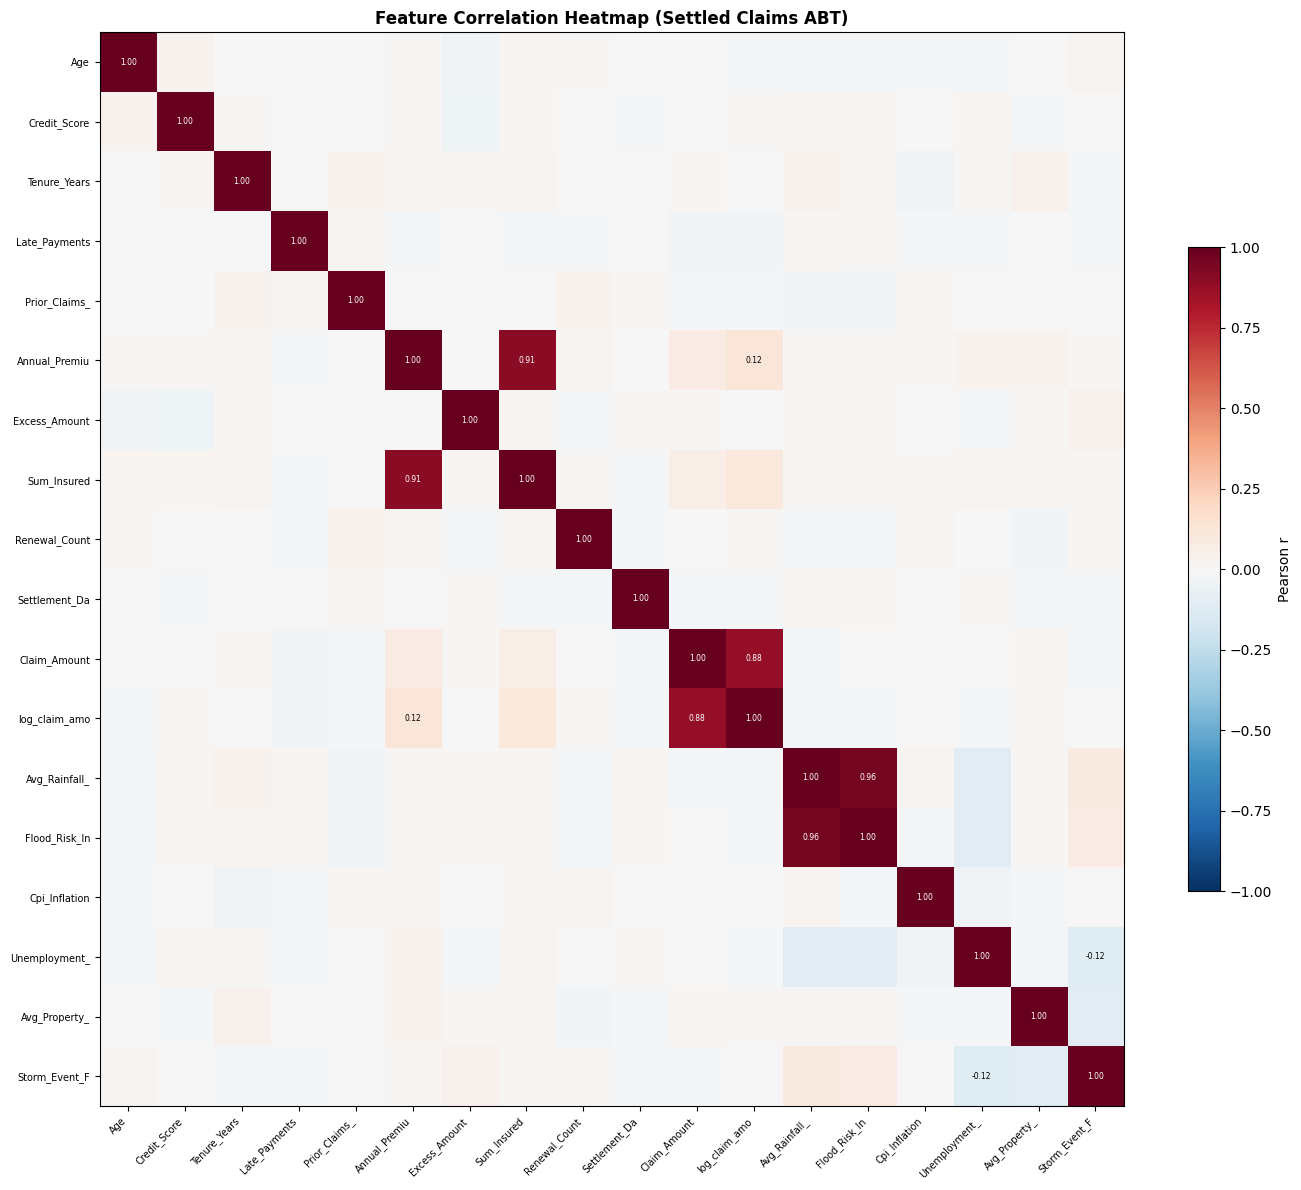

In [40]:
# correlation analysis
num_cols = ['Age', 'Credit Score', 'Tenure Years', 'Late Payments 12M', 'Prior Claims Count',
            'Annual Premium', 'Excess Amount', 'Sum Insured', 'Renewal Count',
            'Settlement Days', 'Claim Amount', 'log_claim_amount',
            'Avg Rainfall Mm', 'Flood Risk Index', 'Cpi Inflation',
            'Unemployment Rate', 'Avg Property Price Gbp', 'Storm Event Flag']
num_cols = [c for c in num_cols if c in abt_settled.columns]
corr_mat = abt_settled[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
short_labels = [c.replace(' ', '_')[:13] for c in corr_mat.columns]
ax.set_xticks(range(len(corr_mat.columns))); ax.set_yticks(range(len(corr_mat.columns)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(short_labels, fontsize=7)
for i in range(len(corr_mat)):
    for j in range(len(corr_mat)):
        v = corr_mat.values[i, j]
        if abs(v) > 0.12:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5.5,
                    color='white' if abs(v) > 0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.6, label='Pearson r')
ax.set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()